In [10]:
import seaborn as sns
import pandas as pd

titanic = sns.load_dataset('titanic')

In [2]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
titanic['age'].isna().sum()

np.int64(177)

In [6]:
survival_rate_before = titanic['survived'].mean()
survival_rate_before

np.float64(0.3838383838383838)

In [7]:
after_removing_df = titanic.dropna(subset=['age'])
after_removing_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [8]:
survival_rate_after = after_removing_df['survived'].mean()
survival_rate_after

np.float64(0.4061624649859944)

In [9]:
print(f"- age 결측치 제거 전 전체 생존율: {survival_rate_before:.2%}")
print(f"- age 결측치 제거 후 생존율: {survival_rate_after:.2%}")
print(f"- 생존율 변화: {survival_rate_after - survival_rate_before:+.2%}")

- age 결측치 제거 전 전체 생존율: 38.38%
- age 결측치 제거 후 생존율: 40.62%
- 생존율 변화: +2.23%


In [11]:
import matplotlib.pyplot as plt

In [20]:
labels = ['Before_Droped', 'After_Dropped)']
rates = [survival_rate_before, survival_rate_after]

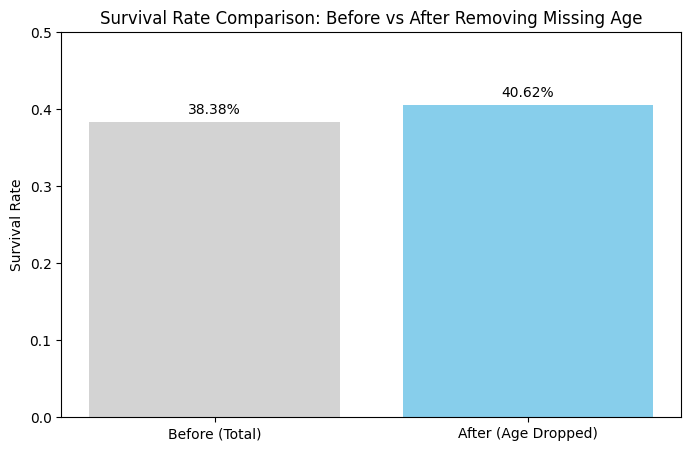

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(labels, rates, color=['lightgray', 'skyblue'])
plt.ylim(0, 0.5)  # 생존율이 보통 0.3~0.4 사이라 범위를 잡아줌
plt.ylabel('Survival Rate')
plt.title('Survival Rate Comparison: Before vs After Removing Missing Age')

for i, v in enumerate(rates):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')

plt.show()